In [1]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import librosa
import librosa.display
import soundfile as sf
import pandas as pd
import ast
import os

/home/bella/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
AUDIO_DIR = "/home/bella/Desktop/chalmers/AML/Project/data/fma_small"
METADATA_DIR = "/home/bella/Desktop/chalmers/AML/Project/data/fma_metadata"

SR = 22050           # sample rate
N_FFT = 1024         # FFT window size
HOP_LENGTH = 256     # hop length
N_MELS = 64          # mel frequency bins

CHUNK_DURATION = 5   # seconds per chunk
OVERLAP = 2.5        # seconds of overlap between chunks

# Derived
CHUNK_FRAMES = int(np.ceil(CHUNK_DURATION * SR / HOP_LENGTH))   # ~431 frames
STRIDE_FRAMES = int(np.ceil((CHUNK_DURATION - OVERLAP) * SR / HOP_LENGTH))  # ~215 frames

print(f"Frames per chunk: {CHUNK_FRAMES}")
print(f"Stride frames: {STRIDE_FRAMES}")
print(f"Chunk shape will be: (1, {N_MELS}, {CHUNK_FRAMES})")

Frames per chunk: 431
Stride frames: 216
Chunk shape will be: (1, 64, 431)


In [3]:
def load_tracks(filepath):
    tracks = pd.read_csv(filepath, index_col=0, header=[0, 1])

    COLUMNS = [('track', 'tags'), ('album', 'tags'), ('artist', 'tags'),
               ('track', 'genres'), ('track', 'genres_all')]
    for column in COLUMNS:
        tracks[column] = tracks[column].map(ast.literal_eval)

    COLUMNS = [('track', 'date_created'), ('track', 'date_recorded'),
               ('album', 'date_created'), ('album', 'date_released'),
               ('artist', 'date_created'), ('artist', 'active_year_begin'),
               ('artist', 'active_year_end')]
    for column in COLUMNS:
        tracks[column] = pd.to_datetime(tracks[column])

    SUBSETS = ('small', 'medium', 'large')
    tracks['set', 'subset'] = pd.Categorical(
        tracks['set', 'subset'], categories=SUBSETS, ordered=True)

    COLUMNS = [('track', 'genre_top'), ('track', 'license'),
               ('album', 'type'), ('album', 'information'),
               ('artist', 'bio')]
    for column in COLUMNS:
        tracks[column] = tracks[column].astype('category')

    return tracks


tracks = load_tracks(os.path.join(METADATA_DIR, 'tracks.csv'))
small = tracks['set', 'subset'] <= 'small'
tracks_small = tracks[small]

electronic = tracks_small['track', 'genre_top'] == 'Electronic'
electronic_tracks = tracks_small[electronic]

print(f"Number of electronic tracks: {len(electronic_tracks)}")

Number of electronic tracks: 1000


In [4]:
def get_audio_path(audio_dir, track_id):
    tid_str = '{:06d}'.format(track_id)
    return os.path.join(audio_dir, tid_str[:3], tid_str + '.mp3')


def mp3_to_mel_chunks(filepath, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
                      n_mels=N_MELS, chunk_frames=CHUNK_FRAMES,
                      stride_frames=STRIDE_FRAMES):
    # Load full track as mono
    y, _ = librosa.load(filepath, sr=sr, mono=True)

    # Compute mel spectrogram of full track
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft,
                                          hop_length=hop_length, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)  # shape: (n_mels, total_frames)

    # Normalize to [-1, 1]  (mel_db ranges roughly from -80 to 0)
    mel_norm = (mel_db + 40) / 40  # centers around 0, range [-1, 1]

    # Slice into overlapping chunks
    chunks = []
    total_frames = mel_norm.shape[1]
    start = 0
    while start + chunk_frames <= total_frames:
        chunk = mel_norm[:, start:start + chunk_frames]  # (n_mels, chunk_frames)
        chunks.append(chunk[np.newaxis, :, :])           # (1, n_mels, chunk_frames)
        start += stride_frames

    return chunks


def mel_chunk_to_audio(chunk, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Convert a single (1, n_mels, chunk_frames) chunk back to audio"""
    mel_norm = chunk.squeeze()             # (n_mels, chunk_frames)
    mel_db = mel_norm * 40 - 40            # denormalize
    mel_power = librosa.db_to_power(mel_db)
    audio = librosa.feature.inverse.mel_to_audio(mel_power, sr=sr,
                                                  n_fft=n_fft,
                                                  hop_length=hop_length)
    return audio

Number of chunks from one track: 10
Each chunk shape: (1, 64, 431)


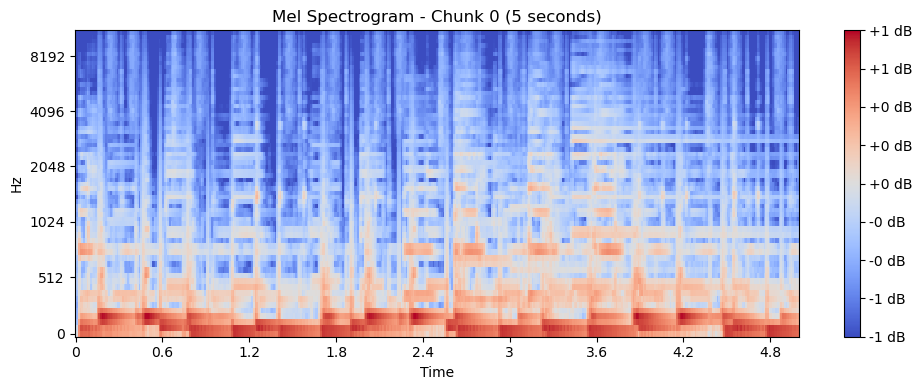

Original (first 5 seconds):


Reconstructed from mel chunk:


In [5]:
electronic_index = electronic_tracks.index.values
electronic_paths = [get_audio_path(AUDIO_DIR, i) for i in electronic_index]

# Test on first track
test_path = electronic_paths[0]
test_chunks = mp3_to_mel_chunks(test_path)

print(f"Number of chunks from one track: {len(test_chunks)}")
print(f"Each chunk shape: {test_chunks[0].shape}")  # should be (1, 64, 431)

# Visualize first chunk
plt.figure(figsize=(10, 4))
librosa.display.specshow(test_chunks[0].squeeze(), sr=SR, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram - Chunk 0 (5 seconds)')
plt.tight_layout()
plt.show()

# Listen to original vs reconstructed
y_original, _ = librosa.load(test_path, sr=SR, mono=True, duration=5)
audio_recon = mel_chunk_to_audio(test_chunks[0])

print("Original (first 5 seconds):")
ipd.display(ipd.Audio(y_original, rate=SR))
print("Reconstructed from mel chunk:")
ipd.display(ipd.Audio(audio_recon, rate=SR))

In [6]:
all_chunks = []
skipped = 0

for i, path in enumerate(electronic_paths):
    try:
        chunks = mp3_to_mel_chunks(path)
        all_chunks.extend(chunks)

        if i % 50 == 0:
            print(f"Processed {i}/{len(electronic_paths)} tracks — "
                  f"{len(all_chunks)} chunks so far")

    except Exception as e:
        print(f"Skipped {os.path.basename(path)}: {e}")
        skipped += 1

print(f"\nDone. Skipped {skipped} tracks.")
print(f"Total chunks: {len(all_chunks)}")

# Stack into dataset array
dataset = np.array(all_chunks, dtype=np.float32)  # (N, 1, 64, 431)
print(f"Dataset shape: {dataset.shape}")
print(f"Memory usage: {dataset.nbytes / 1e9:.2f} GB")

np.save("mel_electronic_dataset.npy", dataset)
print("Saved to mel_electronic_dataset.npy")

Processed 0/1000 tracks — 10 chunks so far
Processed 50/1000 tracks — 510 chunks so far
Processed 100/1000 tracks — 1010 chunks so far
Processed 150/1000 tracks — 1510 chunks so far
Processed 200/1000 tracks — 2010 chunks so far
Processed 250/1000 tracks — 2510 chunks so far
Processed 300/1000 tracks — 3010 chunks so far
Processed 350/1000 tracks — 3510 chunks so far
Processed 400/1000 tracks — 4010 chunks so far
Processed 450/1000 tracks — 4510 chunks so far
Processed 500/1000 tracks — 5010 chunks so far
Processed 550/1000 tracks — 5510 chunks so far


[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
/tmp/ipykernel_7862/465811523.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(filepath, sr=sr, mono=True)
/home/bella/anaconda3/lib/python3.13/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipped 099134.mp3: 
Processed 600/1000 tracks — 6000 chunks so far
Processed 650/1000 tracks — 6500 chunks so far
Processed 700/1000 tracks — 7000 chunks so far
Processed 750/1000 tracks — 7500 chunks so far
Processed 800/1000 tracks — 8000 chunks so far
Processed 850/1000 tracks — 8500 chunks so far
Processed 900/1000 tracks — 9000 chunks so far
Processed 950/1000 tracks — 9500 chunks so far

Done. Skipped 1 tracks.
Total chunks: 9990
Dataset shape: (9990, 1, 64, 431)
Memory usage: 1.10 GB
Saved to mel_electronic_dataset.npy


Min value: -1.000  (should be ~-1)
Max value: 1.000  (should be ~1)
Mean value: -0.040

Random chunk 7329:


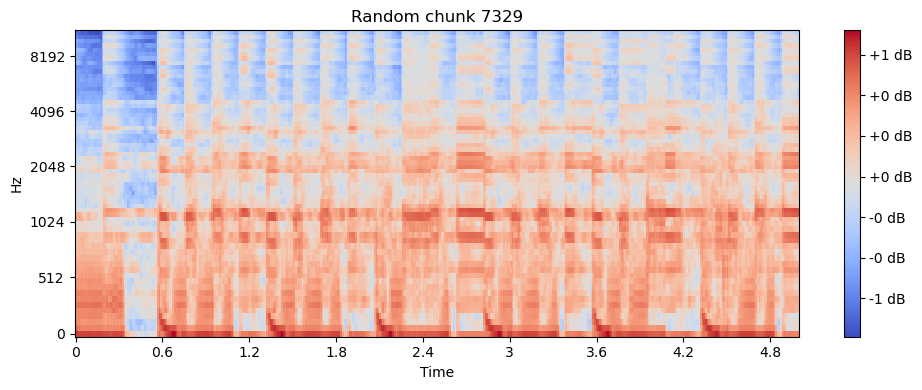

In [7]:
print(f"Min value: {dataset.min():.3f}  (should be ~-1)")
print(f"Max value: {dataset.max():.3f}  (should be ~1)")
print(f"Mean value: {dataset.mean():.3f}")

# Listen to a random chunk
idx = np.random.randint(len(dataset))
audio = mel_chunk_to_audio(dataset[idx])
print(f"\nRandom chunk {idx}:")
ipd.display(ipd.Audio(audio, rate=SR))

# Visualize a random chunk
plt.figure(figsize=(10, 4))
librosa.display.specshow(dataset[idx].squeeze(), sr=SR, hop_length=HOP_LENGTH,
                         x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Random chunk {idx}')
plt.tight_layout()
plt.show()